# вариант 1
## прогноз коэффициента загрузки гостиниц через sarima

в этой работе беру столбец `x1` из файла `data.csv`.
это месячный ряд по загрузке гостиниц в chicago central business district.

известные значения есть с января 1994 года по апрель 2003 года.

так как ряд месячный и сезонность здесь выражена довольно явно, лучше использовать сезонную arima, то есть `sarima`.

In [ ]:
import numpy as np
import pandas as pd
from IPython.display import display
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller
import warnings
import matplotlib.pyplot as plt
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
pd.options.display.float_format = '{:,.3f}'.format

## готовим данные

сначала приведу таблицу к удобному виду

In [2]:
variant_number = 1
column = 'x1'
series_title = 'коэффициент загрузки гостиниц, chicago central business district'
series_unit = '%'

month_map = {
    'January': 1,
    'February': 2,
    'March': 3,
    'April': 4,
    'May': 5,
    'June': 6,
    'July': 7,
    'August': 8,
    'September': 9,
    'October': 10,
    'November': 11,
    'December': 12,
}

month_names_ru = {
    1: 'январь',
    2: 'февраль',
    3: 'март',
    4: 'апрель',
    5: 'май',
    6: 'июнь',
    7: 'июль',
    8: 'август',
    9: 'сентябрь',
    10: 'октябрь',
    11: 'ноябрь',
    12: 'декабрь',
}

raw_data = pd.read_csv('data.csv', sep=';', dtype=str)

# название месяца в номер
raw_data['month_number'] = raw_data['date1'].map(month_map)

# yyyy-mm-01
raw_data['date'] = pd.to_datetime(
    {
        'year': raw_data['date2'].astype(int),
        'month': raw_data['month_number'],
        'day': 1,
    }
)


raw_data[column] = raw_data[column].str.replace(',', '.', regex=False)
raw_data[column] = pd.to_numeric(raw_data[column], errors='coerce')
series = raw_data.set_index('date')[column]

# тренировочный набор
train = series.dropna().copy()
train.index = pd.DatetimeIndex(train.index, freq='MS')

# для предикта
future_dates = pd.DatetimeIndex(series[series.isna()].index, freq='MS')

print('вариант:', variant_number)
print('столбец:', column)
print('известных наблюдений:', len(train))
print('месяцев для прогноза:', len(future_dates))

raw_data[['date', column]].head()
raw_data[['date', column]].tail(12)

вариант: 1
столбец: x1
известных наблюдений: 112
месяцев для прогноза: 8


,date,x1
108,2003-01-01,51.600
109,2003-02-01,52.700
110,2003-03-01,65.000
111,2003-04-01,69.000
112,2003-05-01,NaN
113,2003-06-01,NaN
114,2003-07-01,NaN
115,2003-08-01,NaN
116,2003-09-01,NaN
117,2003-10-01,NaN


## сначала смотрим на ряд

перед подбором модели полезно просто глазами проверить, есть ли тренд и повторяемость по месяцам.

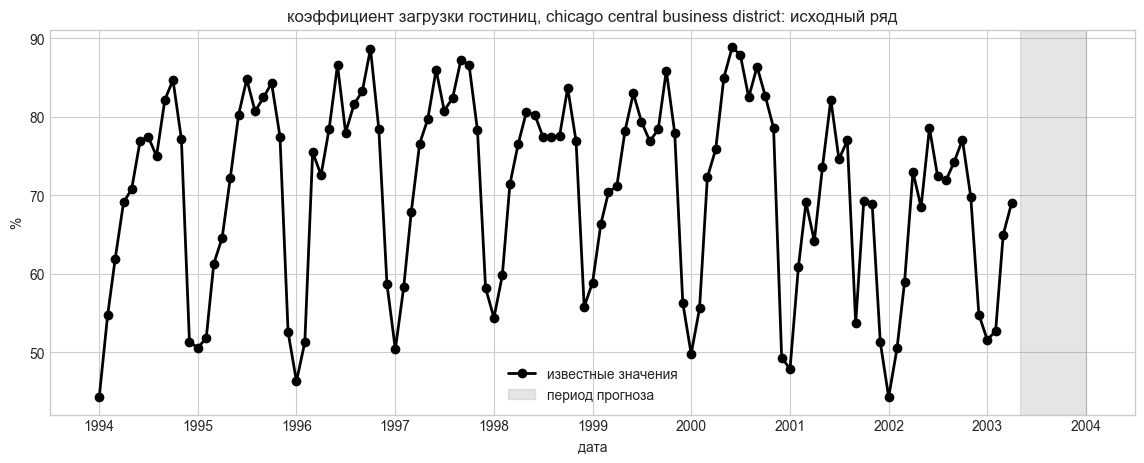

In [7]:
plt.figure(figsize=(14, 5))

# текущий ряд
plt.plot(
    train.index,
    train.values,
    marker='o',
    linewidth=2,
    color='black',
    label='известные значения',
)

# область для прогноза
if len(future_dates) > 0:
    plt.axvspan(
        future_dates[0],
        future_dates[-1] + pd.offsets.MonthEnd(1),
        color='gray',
        alpha=0.2,
        label='период прогноза',
    )

plt.title(f'{series_title}: исходный ряд')
plt.xlabel('дата')
plt.ylabel(series_unit)
plt.legend()

## проверяем стационарность

arima не любит ряд с трендом и сезонностью в исходном виде. поэтому дальше проверю, хватает ли обычной и сезонной разности.

In [9]:
def make_adf_row(values, row_name):
    # adf-тест считаю только по непустым значениям
    clean_values = values.dropna()
    adf_stat, p_value, _, _, _, _ = adfuller(clean_values, autolag='AIC')

    return {
        'ряд': row_name,
        'наблюдений': len(clean_values),
        'adf-статистика': adf_stat,
        'p-value': p_value,
    }

# обычная разность по соседним месяцам
diff_1 = train.diff()
# сезонная разность по тому же месяцу прошлого года
diff_12 = train.diff(12)
# комбинирую оба преобразования
stationary_series = train.diff().diff(12).dropna()

adf_rows = []
adf_rows.append(make_adf_row(train, 'исходный ряд'))
adf_rows.append(make_adf_row(diff_1, 'обычная разность, d=1'))
adf_rows.append(make_adf_row(diff_12, 'сезонная разность, D=1, s=12'))
adf_rows.append(make_adf_row(stationary_series, 'обычная и сезонная разность вместе'))

adf_table = pd.DataFrame(adf_rows)
display(adf_table)

print(
    'дальше беру d=1 и D=1, потому что после этих преобразований '
    'ряд уже выглядит стационарным по adf-тесту.'
)

,ряд,наблюдений,adf-статистика,p-value
0,исходный ряд,112,-1.259,0.648
1,"обычная разность, d=1",111,-5.665,0.000
2,"сезонная разность, D=1, s=12",100,-4.073,0.001
3,обычная и сезонная разность вместе,99,-3.023,0.033


дальше беру d=1 и D=1, потому что после этих преобразований ряд уже выглядит стационарным по adf-тесту.


## смотрим acf и pacf

после дифференцирования посмотрю, на каких лагах еще держится связь. по этим графикам проще выбрать несколько кандидатов, чем перебирать модели совсем вслепую.

Text(0.5, 1.0, 'pacf для преобразованного ряда')

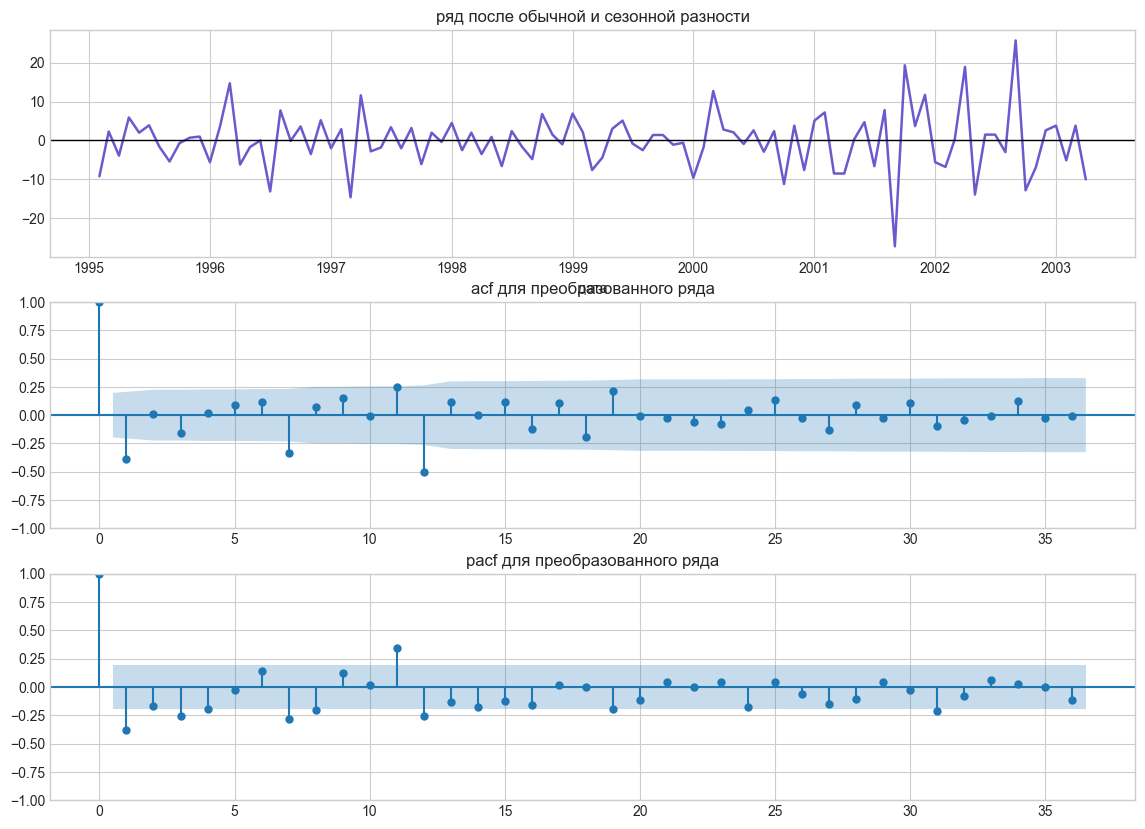

In [10]:
fig, axes = plt.subplots(3, 1, figsize=(14, 10))

# сам преобразованный ряд
axes[0].plot(
    stationary_series.index,
    stationary_series.values,
    color='slateblue',
    linewidth=1.8,
)
axes[0].axhline(0, color='black', linewidth=1)
axes[0].set_title('ряд после обычной и сезонной разности')
axes[0].set_xlabel('дата')

# acf показывает общую автокорреляцию
plot_acf(stationary_series, lags=36, ax=axes[1])
axes[1].set_title('acf для преобразованного ряда')

# pacf показывает частичную автокорреляцию
plot_pacf(stationary_series, lags=36, ax=axes[2], method='ywm')
axes[2].set_title('pacf для преобразованного ряда')

## сравниваем несколько моделей

чтоьы не брать первую попавшуюся модель, можно сделать короткую проверку

- последние 12 известных месяцев откладываю для валидации;
- несколько разумных моделей обучаю на более раннем участке;
- потом сравниваю их по `aic`, ошибке прогноза и по тесту ljung-box для остатков.

In [12]:
# ранняя часть ряда пойдет на обучение
train_part = train.iloc[:-12].copy()

# последние 12 известных точек оставляю для проверки прогноза
valid_part = train.iloc[-12:].copy()


def calc_errors(real_values, predicted_values):
    absolute_errors = np.abs(real_values - predicted_values)
    squared_errors = (real_values - predicted_values) ** 2
    relative_errors = np.abs((real_values - predicted_values) / real_values)

    mae = absolute_errors.mean()
    rmse = np.sqrt(squared_errors.mean())
    mape = relative_errors.mean() * 100

    return mae, rmse, mape


candidate_models = [
    ('sarima(0, 1, 1) x (0, 1, 1, 12)', (0, 1, 1), (0, 1, 1, 12), 'простая сезонная модель'),
    ('sarima(1, 1, 1) x (0, 1, 1, 12)', (1, 1, 1), (0, 1, 1, 12), 'добавил один ar-коэффициент'),
    ('sarima(2, 1, 1) x (2, 1, 1, 12)', (2, 1, 1), (2, 1, 1, 12), 'более гибкая модель по сезону'),
    ('sarima(1, 1, 0) x (1, 1, 1, 12)', (1, 1, 0), (1, 1, 1, 12), 'еще один умеренный вариант'),
]

comparison_rows = []

for model_label, order, seasonal_order, note in candidate_models:
    # обучаю модель на тренировочном куске
    candidate_model = SARIMAX(
        train_part,
        order=order,
        seasonal_order=seasonal_order,
        enforce_stationarity=False,
        enforce_invertibility=False,
    )
    candidate_fit = candidate_model.fit(disp=False)

    # прогнозирую длину validation-отрезка
    validation_forecast = candidate_fit.get_forecast(steps=len(valid_part)).predicted_mean

    mae, rmse, mape = calc_errors(valid_part, validation_forecast)

    # отдельно смотрю, не осталось ли структуры в остатках
    lb_table = acorr_ljungbox(
        candidate_fit.resid.dropna(),
        lags=[12],
        return_df=True,
    )
    lb_pvalue = lb_table['lb_pvalue'].iloc[0]

    comparison_rows.append(
        {
            'модель': model_label,
            'aic': candidate_fit.aic,
            'bic': candidate_fit.bic,
            'mae на валидации': mae,
            'rmse на валидации': rmse,
            'mape на валидации, %': mape,
            'p-value ljung-box': lb_pvalue,
            'сошлась': candidate_fit.mle_retvals.get('converged'),
            'описание': note,
        }
    )

comparison_table = pd.DataFrame(comparison_rows)
comparison_table = comparison_table.sort_values(
    by=['rmse на валидации', 'aic']
).reset_index(drop=True)

display(comparison_table)

,модель,aic,bic,mae на валидации,rmse на валидации,"mape на валидации, %",p-value ljung-box,сошлась,описание
0,"sarima(0, 1, 1) x (0, 1, 1, 12)",450.890,457.761,2.757,3.400,4.402,0.003,True,простая сезонная модель
1,"sarima(1, 1, 1) x (0, 1, 1, 12)",449.564,458.726,3.141,3.919,5.063,0.075,True,добавил один ar-коэффициент
2,"sarima(2, 1, 1) x (2, 1, 1, 12)",384.731,399.507,3.274,4.592,5.314,0.742,True,более гибкая модель по сезону
3,"sarima(1, 1, 0) x (1, 1, 1, 12)",468.961,478.177,4.460,4.772,6.768,0.017,True,еще один умеренный вариант


## какую модель беру в итог

по `rmse` на отложенных 12 месяцах чуть лучше выглядит простая `sarima(0, 1, 1) x (0, 1, 1, 12)`.  
но у нее маленький `p-value` по `ljung-box`, то есть в остатках еще остается заметная структура.

поэтому в итоговую часть беру sarima(2, 1, 1) * (2, 1, 1, 12):

- у нее заметно лучше `aic`;
- остатки выглядят гораздо чище;
- сезонную форму ряда она описывает аккуратнее.

In [18]:
selected_order = (2, 1, 1)
selected_seasonal_order = (2, 1, 1, 12)
selected_model_name = 'sarima(2, 1, 1) x (2, 1, 1, 12)'

# теперь обучаю итоговую модель уже на всех известных наблюдениях
final_model = SARIMAX(
    train,
    order=selected_order,
    seasonal_order=selected_seasonal_order,
    enforce_stationarity=False,
    enforce_invertibility=False,
)
final_fit = final_model.fit(disp=False)

# fitted values нужны, чтобы посмотреть, как модель описывает историю
fitted_values = final_fit.get_prediction(
    start=train.index[0],
    end=train.index[-1],
).predicted_mean

# старт с 13 точек см
warmup_observations = 13
real_tail = train.iloc[warmup_observations:]
fitted_tail = fitted_values.iloc[warmup_observations:]

fit_mae = np.mean(np.abs(real_tail - fitted_tail))
fit_rmse = np.sqrt(np.mean((real_tail - fitted_tail) ** 2))

metrics_table = pd.DataFrame(
    {
        'показатель': [
            'выбранная модель',
            'aic',
            'bic',
            'mae на известной части ряда',
            'rmse на известной части ряда',
        ],
        'значение': [
            selected_model_name,
            round(final_fit.aic, 3),
            round(final_fit.bic, 3),
            round(fit_mae, 3),
            round(fit_rmse, 3),
        ],
    }
)

params_table = pd.DataFrame(
    {
        'параметр': final_fit.params.index,
        'оценка': final_fit.params.values,
        'p-value': final_fit.pvalues.values,
    }
)

display(metrics_table)
display(params_table)

,показатель,значение
0,выбранная модель,"sarima(2, 1, 1) x (2, 1, 1, 12)"
1,aic,452.800
2,bic,468.833
3,mae на известной части ряда,3.782
4,rmse на известной части ряда,5.402


,параметр,оценка,p-value
0,ar.L1,0.313,0.107
1,ar.L2,-0.022,0.907
2,ma.L1,-0.812,0.000
3,ar.S.L12,-0.519,0.060
4,ar.S.L24,-0.349,0.139
5,ma.S.L12,-0.443,0.120
6,sigma2,23.056,0.000


## смотрим на остатки

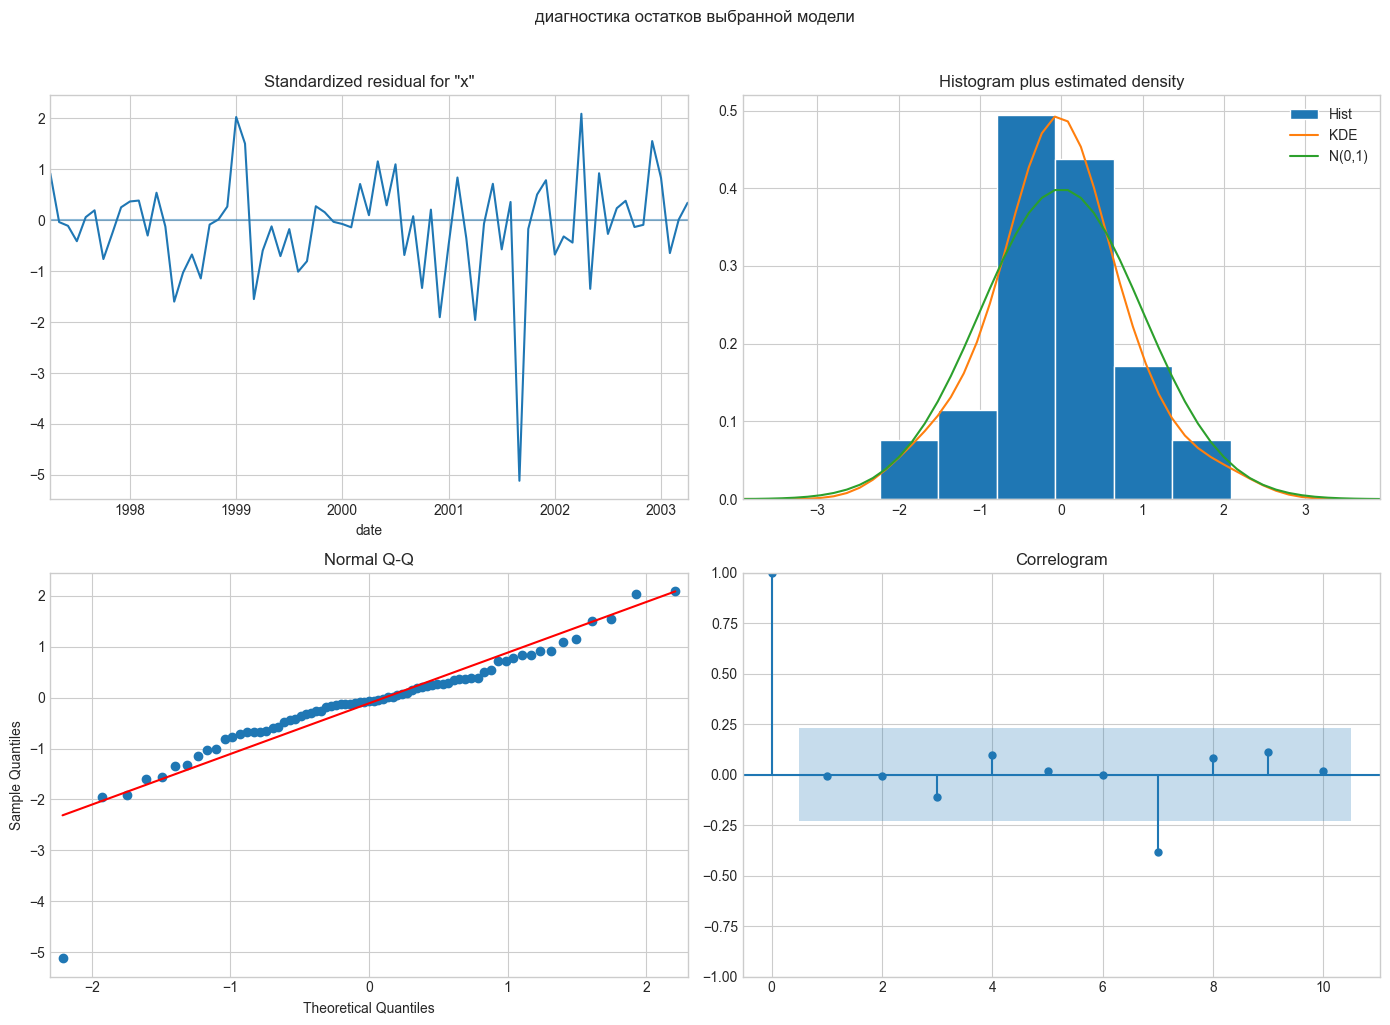

,лаг,статистика ljung-box,p-value
0,6,1.557,0.956
1,12,11.227,0.510
2,24,17.250,0.838


In [17]:
# стандартная диагностика из statsmodels
diagnostic_figure = final_fit.plot_diagnostics(figsize=(14, 10))
diagnostic_figure.suptitle('диагностика остатков выбранной модели', y=1.02)
plt.tight_layout()
plt.show()

# дополнительно считаю ljung-box на нескольких лагах
ljung_box_table = acorr_ljungbox(
    final_fit.resid.dropna(),
    lags=[6, 12, 24],
    return_df=True,
).reset_index()

ljung_box_table = ljung_box_table.rename(
    columns={
        'index': 'лаг',
        'lb_stat': 'статистика ljung-box',
        'lb_pvalue': 'p-value',
    }
)

display(ljung_box_table)

## строим прогноз

теперь модель уже обучена на всей известной части ряда, поэтому можно переходить к след 8 мес

,месяц,"прогноз, %",нижняя граница 95%,верхняя граница 95%
0,май 2003,75.740,66.330,85.150
1,июнь 2003,80.500,69.980,91.030
2,июль 2003,77.090,66.130,88.040
3,август 2003,74.780,63.520,86.050
4,сентябрь 2003,72.750,61.210,84.300
5,октябрь 2003,76.220,64.410,88.030
6,ноябрь 2003,71.430,59.360,83.500
7,декабрь 2003,47.590,35.260,59.910


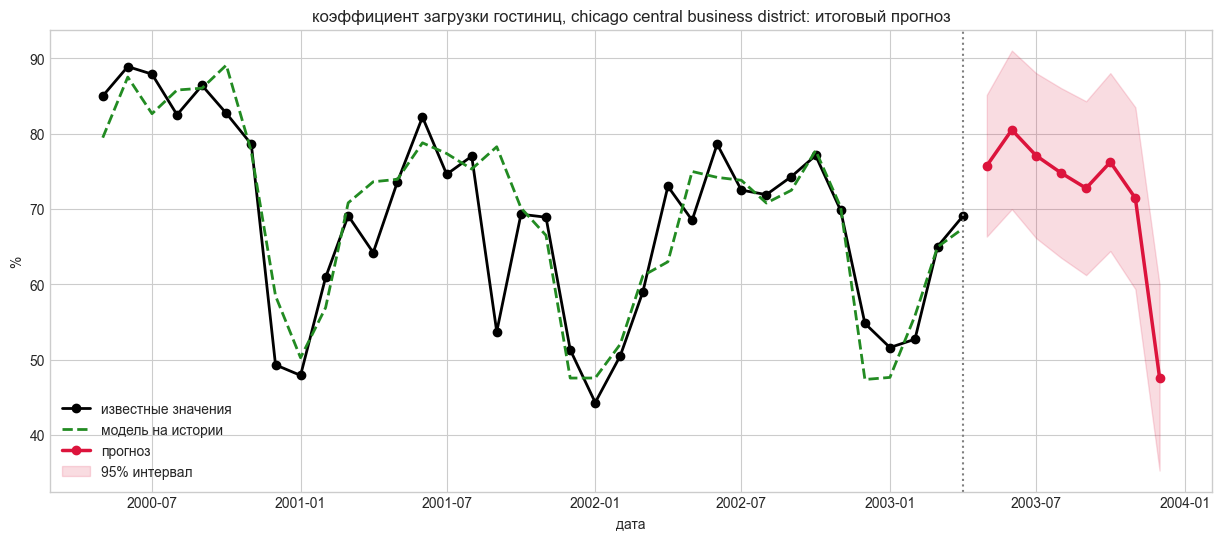

In [9]:
# прогноз строю ровно на столько месяцев, сколько пропусков стоит в конце ряда
forecast_result = final_fit.get_forecast(steps=len(future_dates))
forecast_mean = forecast_result.predicted_mean
forecast_interval = forecast_result.conf_int(alpha=0.05)

forecast_rows = []

for current_date, point_forecast in forecast_mean.items():
    lower_bound = forecast_interval.loc[current_date].iloc[0]
    upper_bound = forecast_interval.loc[current_date].iloc[1]

    forecast_rows.append(
        {
            'месяц': f'{month_names_ru[current_date.month]} {current_date.year}',
            'прогноз, %': point_forecast,
            'нижняя граница 95%': lower_bound,
            'верхняя граница 95%': upper_bound,
        }
    )

forecast_table = pd.DataFrame(forecast_rows).round(2)
display(forecast_table)

# для картинки беру последние 36 известных месяцев, чтобы график не был слишком длинным
plot_start = train.index[-36]
recent_actual = train.loc[plot_start:]
recent_fitted = fitted_values.loc[plot_start:]

plt.figure(figsize=(15, 6))

plt.plot(
    recent_actual.index,
    recent_actual.values,
    marker='o',
    linewidth=2,
    color='black',
    label='известные значения',
)

plt.plot(
    recent_fitted.index,
    recent_fitted.values,
    linewidth=2,
    linestyle='--',
    color='forestgreen',
    label='модель на истории',
)

plt.plot(
    forecast_mean.index,
    forecast_mean.values,
    marker='o',
    linewidth=2.5,
    color='crimson',
    label='прогноз',
)

plt.fill_between(
    forecast_mean.index,
    forecast_interval.iloc[:, 0].values,
    forecast_interval.iloc[:, 1].values,
    color='crimson',
    alpha=0.15,
    label='95% интервал',
)

plt.axvline(train.index[-1], color='gray', linestyle=':', linewidth=1.5)
plt.title(f'{series_title}: итоговый прогноз')
plt.xlabel('дата')
plt.ylabel(series_unit)
plt.legend()
plt.show()

## вывод

исходный ряд в таком виде для arima не подходит, потому что в нем есть и тренд, и годовая сезонность. после обычной и сезонной разности ряд стал заметно спокойнее, и уже на нем можно было подбирать модель.

в итог взял `sarima(2, 1, 1) x (2, 1, 1, 12)`. она оказалась не самой простой, но зато лучше описывает структуру ряда и дает более аккуратные остатки.

по прогнозу видно, что летом 2003 года загрузка гостиниц остается высокой, примерно в районе 75-80%. дальше к концу года идет снижение, и самое низкое значение ожидается в декабре.